# Comprobación de Supuestos de Estacionariedad en Ruido Blanco
# (Media, Varianza y Función de Autocorrelación)

## Cargar librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

## Series Temporales y Su estacionariedad

Al analizar una serie temporal $z$ es posible considerarla una realización particular de un proceso estocástico. Para este propósito se considerarán únicamente series equiespaciadas indexadas en tiempo discreto, esposible considerar otra variable en vez del tiempo pero usualmente resulta conveniente pensarlo así. Y donde cada obsercación pertenece a una variable aleatoria $N$-dimensional $\,(z_{1}, z_{2}, \dots,z_{N})$ con distribución de probabilidad conjunta $p(z_{1}, z_{2}, \dots,z_{N})$.

Como menciona Box et al (2016) una de las principales carácteristicas en las series temporales es la asunción de un cierto equlibrio estadístico. **La estacionariedad** es un supuesto con estas caractísticas relativamente últi pero excesivamente restrictivo. Las series temporales de este tipo puedente ser facilmente descritas apartir de su media, varianza y *función de autocorrelación* o, de forma equivalente, con su media, varianza y su *función densidad espectral*.

Uno de los procesos más sencillos es el ruido blanco o también llamado interferencia aleatoria es el que se simulará de forma seudo-aleatoria con la función librería *ramdom* de *numpy*, con distribución marginal normal $a_t \sim \mathcal{N}(0, 1)$ y semilla fija. Más adelante se definirá el proceso ruido blanco (**white noise*) y algunas de sus propiedades. Las siguientes tablas contiene los datos simulados con muestras de 50, 100, 150 y 200 y su representación gráfica como serie temporal.

In [4]:
random = np.random.RandomState(1039834) 
ls_wn = [] 
cant = 0 
rng = np.random.default_rng()

for _ in range(4): 
    cant += 50 
    wn_df = pd.DataFrame({ 
        "ds": np.arange(1, cant + 1), 
        "white_noise": rng.normal(0,1,cant) }) 
    ls_wn.append(wn_df)

tabs = []

for df in ls_wn:

    with pd.option_context(
        'display.max_rows', 10,
        'display.min_rows', 10
    ):
        resumen = repr(df)

    tabla = widgets.HTML(
        value=f"<pre>{resumen}</pre>"
    )

    tabs.append(widgets.VBox([tabla]))

    
tab = widgets.Tab(children=tabs)

for i, n in enumerate([50, 100, 150, 200]):
    tab.set_title(i, f"wn-{n}")

display(tab)

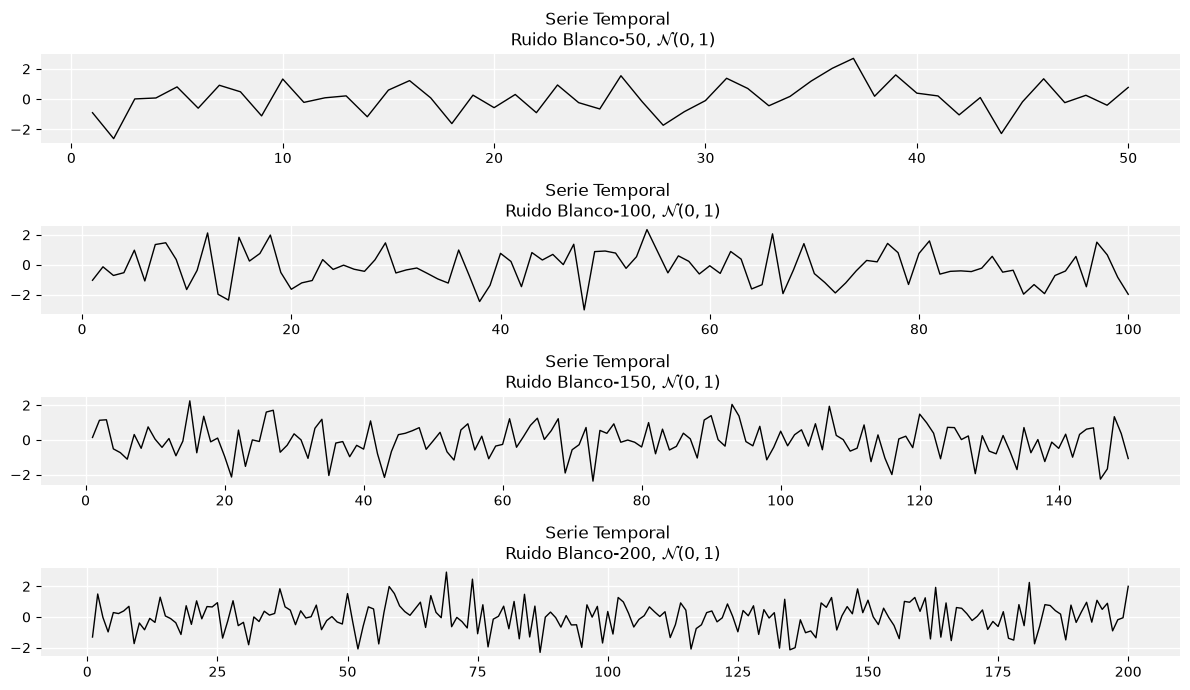

In [5]:
# 1. Agrupar tus DataFrames independientes y títulos en listas

titulos = [
    "Serie Temporal \n Ruido Blanco-50, $\\mathcal{N}(0, 1)$",
    "Serie Temporal \n Ruido Blanco-100, $\\mathcal{N}(0, 1)$",
    "Serie Temporal \n Ruido Blanco-150, $\\mathcal{N}(0, 1)$",
    "Serie Temporal \n Ruido Blanco-200, $\\mathcal{N}(0, 1)$"
]

# 2. Crear el lienzo (fig) y los 4 paneles (axes) en una malla de 2x2
# Nota: Ajustamos el tamaño a [12, 7] para que los 4 paneles respiren bien
fig, axes = plt.subplots(4, 1, figsize=(12, 7))

# 3. Iterar sobre cada panel y aplicar tu estilo base a cada uno
for ax, df, titulo in zip(axes.ravel(), ls_wn, titulos):
    # Graficar la serie en el panel actual (ax)
    ax.plot(df["ds"], df["white_noise"], color="black", linewidth=1)
    ax.set_title(titulo)
    
    # Aplicar tu configuración de fondo y cuadrícula al panel actual
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, color="white", linestyle="-", linewidth=1)

   
    # Ocultar los bordes (spines) de este panel específico
    for lado in ["top", "bottom", "right", "left"]:
        ax.spines[lado].set_visible(False)

# 4. Ajustar el espaciado para que no se solapen los títulos y mostrar
plt.tight_layout()
plt.show()
    

## Proceso estocástico estacionario

Se dice que un proceso estocástico es **estacionario** cuando todas sus propiedades estadísticas (momentos) permanecen constantes o, lo que es equivalente, en equilibrio estadístico en cualquier corrimiento tanto hacia adelante como hacia atras del origen temporal de la serie principal. Esto quiere decir que, $m$ observaciones de una serie $z = z_{t_1}, z_{t_2}, \dots,z_{t_m}$ en los momentos $t_1, t_2, \dots,t_m$ su distribución conjunta es la misma a $m$ observaciones desplazadas $k$ cantidades enteras  del origen tempora inicial, con $z = z_{{t_1}+k}, z_{{t_2}+k}, \dots, z_{{t_m}+k}$ en los momentos  $t_{1}+k, t_{2}+k, \dots, t_{m}+k$.

Dado que cada variable aleatoria para un proceso estrictamente estacionario tiene la misma distribución de probabilidad $p(z_t)$ en cualquier tiempo $t$, es posible deducir su forma a través del histograma con base en la serie temporal observadas.

Por las características del proceso su valor esperado es constante y es el nivel sobre el cual fluctua con varianza constante: 

$$\mu = E[z_t] = \int_{-\infty}^{\infty} zp(z) \, dz, \tag{1}$$

$$\sigma^2_z = E[(z_t - \mu)^2] = \int_{-\infty}^{\infty} (z - \mu)^2 p(z) \, dz. \tag{2}$$

Tanto el esperado como la varianza es posible estimarlo a partir de la serie observada con la media muestral como con la varianza muestral respectivamente

$$ \bar{z} = \frac{1}{N} \sum_{t=1}^{N} z_t, \tag{3}$$

$$ \hat{\sigma}_z^2 = \frac{1}{N} \sum_{t=1}^{N} (z_t-\bar{z})^2. \tag{4}$$

Se puede apreciar a través de los siguientes histogramas para cada una de las muestras de ruido blanco una proximación de los datos a una distribución normal y, también, apartir del cálculo de la media muestra (3) y la varianza muestral (4) son aproximadas a $0$ y $1$ respectivamente.

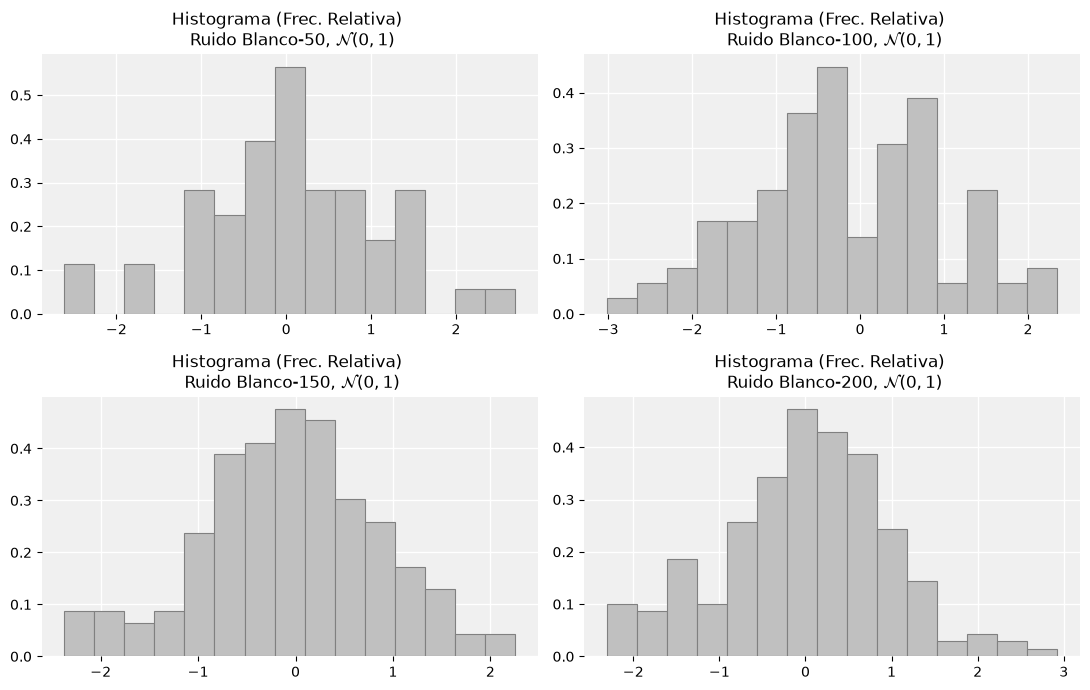

In [6]:
# 1. Limpiar gráficos anteriores de la memoria
plt.close('all')

titulos_hist = [
    "Histograma (Frec. Relativa) \n Ruido Blanco-50, $\\mathcal{N}(0, 1)$",
    "Histograma (Frec. Relativa) \n Ruido Blanco-100, $\\mathcal{N}(0, 1)$",
    "Histograma (Frec. Relativa) \n Ruido Blanco-150, $\\mathcal{N}(0, 1)$",
    "Histograma (Frec. Relativa) \n Ruido Blanco-200, $\\mathcal{N}(0, 1)$"
]

# 2. Crear la malla de 2x2 paneles independientes
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# 3. Iterar sobre los paneles y tus DataFrames en ls_wn
for ax, df, titulo in zip(axes.ravel(), ls_wn, titulos_hist):
    
    # IMPORTANTE: Añadimos zorder=2 para que las barras queden en la capa intermedia
    ax.hist(df["white_noise"], bins=15, density=True, color="#c0c0c0", edgecolor="#808080", linewidth=0.8, zorder=2)
    ax.set_title(titulo)
    
    # Tu estética base personalizada
    ax.set_facecolor("#f0f0f0")
    
    # IMPORTANTE: Añadimos zorder=3 para que las líneas blancas se dibujen por encima de las barras (capa superior)
    ax.grid(True, color="white", linestyle="-", linewidth=1, zorder=3)
    
    # Ocultar los bordes (spines) de este panel específico
    for lado in ["top", "bottom", "right", "left"]:
        ax.spines[lado].set_visible(False)

# 4. Ajustar el diseño para evitar solapamientos y renderizar la imagen
plt.tight_layout()
plt.show()

In [7]:
datos = []
for i in range(4):
    med_var = {
        "media": ls_wn[i]["white_noise"].mean(),
        "varianza": ls_wn[i]["white_noise"].var()
    }
    datos.append(med_var)

med_var_wn = pd.DataFrame(datos)
med_var_wn.insert(0, "tam_muestra_wn", [50, 100, 150, 200])                      
med_var_wn.style.set_properties(**{
    'background-color': 'white',
    'color': 'black',
    'border-color': 'lightgray'
})

,tam_muestra_wn,media,varianza
0,50,0.078436,1.108981
1,100,-0.170404,1.290577
2,150,-0.049722,0.851887
3,200,0.012412,0.940252


### Autocovarianza y Autocorrelación

El supuesto de estacionariedad implica que las distribuciones conjuntas $p(z_{t_1}, z_{t_2})$ a intervalos equiespaciados es la misma en cualquier tiempo $t_1$ y $t_2$. 
También, establece que la autocovarianza entre $z_t$ y $z_{t+k}$, separados por un lag $k$, es la misma en cualquier momento $t$.

$$\gamma_k = cov[z_t, z_{t+k}] = E[(z_t - \mu)(z_{t+k} - \mu)]. \tag{5}$$

La autocorrelación 

$$ \rho_k = \frac{E[(z_t - \mu)(z_{t+k} - \mu)]}{\sqrt{E[(z_t - \mu)^2]E[(z_{t+k} - \mu)^2]}} $$

$$ = \frac{E[(z_t - \mu)(z_{t+k} - \mu)]}{\sigma_z^2}. \tag{6}$$

Dado que, en un proceso ruido blanco es estacionario con media $\mu = 0$ y varianza $\sigma^2$ constante. Es posbile demostrar 
que tanto la autocovarianza como la autocorrelación para dicho proceso es 0 en cualquier retardo (*lag*) $k>0$.

$$\gamma_k = cov[z_t, z_{t+k}] = E[(z_t - 0)(z_{t+k} - 0)]$$

$$\gamma_k = E[(z_t - 0)(z_{t+k} - 0)]$$

Dado que, el proceso es independiente es posbile calcular el esperado de cada factor

$$\gamma_k = E(z_t) E(z_{t+k})$$

Por lo tanto como la media del proceso es cero en cualquier tiempo $t$

$$\gamma_k = 0 \cdot 0 = 0$$

Es decir que 

$$ \rho_k = 0/\sigma_z^2 = 0$$

Para la autocorrelación y autocovarianza en el *lag* 0

$$\gamma_0 = E[(z_t - 0)(z_t - 0)]$$

$$\gamma_0 = E(z_t^2)$$

la varianza se define como: 

$$ Var(z) = E(z_t^2) - [E(z_t)]^2$$

El esperado del segundo término es $0$.

Por lo tanto la autocovarianza de un proceso ruido blanco en el *lag* $0$ es igual a

$$\gamma_0 = \sigma_z^2 $$

y su autocorrelación es igual a

$$\rho_k = \sigma_z^2 / \sigma_z^2 = 1$$

## Proceso Ruido Blanco

El proceso estacionario ruido blanco o también llamado interferencia aleatoria es una clase de proceso de estacionariedad estricta con variables aleatorias denotadas como $a_1, a_2, \dots, a_t, \dots$, independientes e identicamente distribuidas (iid), y función de distribución marginal normal aunque no es necesario, y con media $\mu = 0$ y varianza $\sigma_a^2$ que para este caso en particular será $1$ ($a_t \sim \mathcal{N}[\mu, \ \sigma^2]$). Los valores se generarán de forma pseudo 
aleatoria. Dado que, hay un supuesto de indepencia entre cada una de las variables aleatorias ${a_t}$ su función de autocovarianza 
adquiere la siguiente forma sencilla:

$$\gamma_{k} =  E[a_ta_{t+k}] = \begin{cases} \sigma^2_a \qquad k = 0 \\ 0 \qquad \ \ k \neq 0 \end{cases}$$

El proceso ruido blanco es un caso particular de un proceso *gaussiano*, es decir der distribución normal multivariante, con variables aleatorias totalmente independientes 
y covarianza constante en un punto consigo mismo. Es decir, varianza $\sigma^2$ en el lag $k = 0$ y $0$ en cualquier otro caso $k \neq 0$. Es posbible considerar 
procesos de *estacionariedad debíl* donde solo se reponde a ciertas propiedades estadísticas (momentos) de orden $f$.

## Matriz de Autocovarianza y Autocorrelación de Proceso Ruido Blanco

Las matrices asociadas de autocovarianza ($\mathbf{\Gamma}_n$) y autocorrelación ($\mathbf{P}_n$) para un proceso estacionario dada una sucesión de
observaciones $z_1, z_2,\dots, z_n$ hasta el tiempo $n$, se definen como:

$$\mathbf{\Gamma}_n = 
\begin{bmatrix}
\gamma_0 & \gamma_1 & \gamma_2 & \cdots & \gamma_{n-1} \\
\gamma_1 & \gamma_0 & \gamma_1 & \cdots & \gamma_{n-2} \\
\gamma_2 & \gamma_1 & \gamma_0 & \cdots & \gamma_{n-3} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\gamma_{n-1} & \gamma_{n-2} & \gamma_{n-3} & \cdots & \gamma_0
\end{bmatrix}$$

$$= \sigma_z^2 
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-3} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & 1
\end{bmatrix}
= \sigma_z^2 \mathbf{P}_n \tag{7}$$

Y son simétricas y con elementos constantes en cualquier diagonal. Para el caso particular de ruido blanco, dado que, la varianza es igual $1$ 
para cada $a_t$ la matriz de autocovarianza como la matriz de autocorrelación adquiere la siguiente forma sencilla

$$\mathbf{\Gamma}_n = 
\begin{bmatrix}
\sigma_a^2 & 0 & 0 & \cdots & 0 \\
0 & \sigma_a^2 & 0 & \cdots & 0 \\
0 & 0 & \sigma_a^2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \sigma_a^2
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{bmatrix}$$

$$= \sigma_z^2 
\begin{bmatrix}
1 & 0 & 0 & \cdots & 0 \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{bmatrix}
= \sigma_z^2 \mathbf{P}_n$$

Donde en ambas matrices cada elemento de la digonal principal está compuesta por $1$ y los demás elementos son $0$.

Una de las condiciones que satisfase la matriz de autocorrelación es que es definida como positiva, lo cual implica que su determinante y todos
los principales menores son mayores que cero. Para el caso de ruido blanco

$$|\mathbf{P}_n|=1 \tag{8}$$

su determinante siempre es $1$.

## Estacionariedad de Funciones Lineales

Otra consideración importante pero que no se revisará en esta lienas es que una combinación lineal de un proceso estacionario $z_t$ con coeficientes
invariantes en el tiempo $l_1, l_2, \dots, l_n$ sin ser las $l$'s todas cero, su funcion de autocorrelación sigue sigendo definida positiva
para cualquier conbinación lineal con el proceso estacionario. Incluso se puede extender a infinitas operaciones lineales o infinitos filtros lineales (invariantes en el tiempo)
bajo la condición de sumabilidad absoluta.

## Funciones de Autocovarianza y Autocorrelación

Al gráfico de los valores de la autocovarianza $\gamma_k$ con respecto (en función del) al retardo $k$ se le denomina 
*función de autocovarianza* del proceso. Y de forma semejante al gráfico de los valores de la autocorrelación $\rho_k$ en función del retardo $k$ se
le denomina *función de autocorrelación* del proceso. Dado que la matriz de autocorrelación es simétrica con respecto a la diagonal principal, es decir
$\rho_k=\rho_-k$ en la práctrica solo se suele graficar únicamente la mitad positiva de la función también llamada en el pasado *correlograma*.

## Estimación de las funciones de Autocovarianza y Autocorrelación

De las estimaciones propuestas por varios autores para las funciones de autocovarianza y autocorrelación las más satisfatoria 
para el retardo k-ésimo es

$$r_k = \hat{\rho}_k = \frac{c_k}{c_0} \tag{9}$$

donde

$$c_k = \hat{\gamma}_k = \frac{1}{N} \sum_{t=1}^{N-k} (z_t - \bar{z})(z_{t+k} - \bar{z}) \quad k = 0, 1, 2, \dots, K \tag{10}$$

es el estimador de la autocovarianza $\gamma_k$ considerando que $\gamma_0$ es la varianza del proceso en el retardo $0$,
 con $\bar{z}$ como la media muestral. Los valores del estimador de autocorrelación $r_k$ también es llamado función de autocorrelación muestral.

Con base en box et.al (2016) para obtener una estimación útil de la función de autocorrelación muestral se requieren por lo menos $50$ observaciones, y
las autocorrelaciones estimadas $r_k$ con $k = 0, 1, \dots, K$ con $K$ no mayor a $N/4$.

La siguiente tabla contiene la cantidad de autocorrelaciones a estimar con base en la muestras de ruido blanco de 50, 100, 150, 200 y los fórmula $N/4$. Los gráficos son las funciones de autocorrelación muestrales y sus límites de confianza de la función de autocorrelación.

In [8]:
# Cantidad de autocorrelaciones a estimar

cant_acf = pd.DataFrame({
    "tam_muestra_wn": [50, 100, 150, 200]
})

cant_acf["cantidad"] = np.ceil(cant_acf["tam_muestra_wn"]/4).astype(int)

cant_acf.style.set_properties(**{
    'background-color': 'white',
    'color': 'black',
    'border-color': 'lightgray'
})

,tam_muestra_wn,cantidad
0,50,13
1,100,25
2,150,38
3,200,50


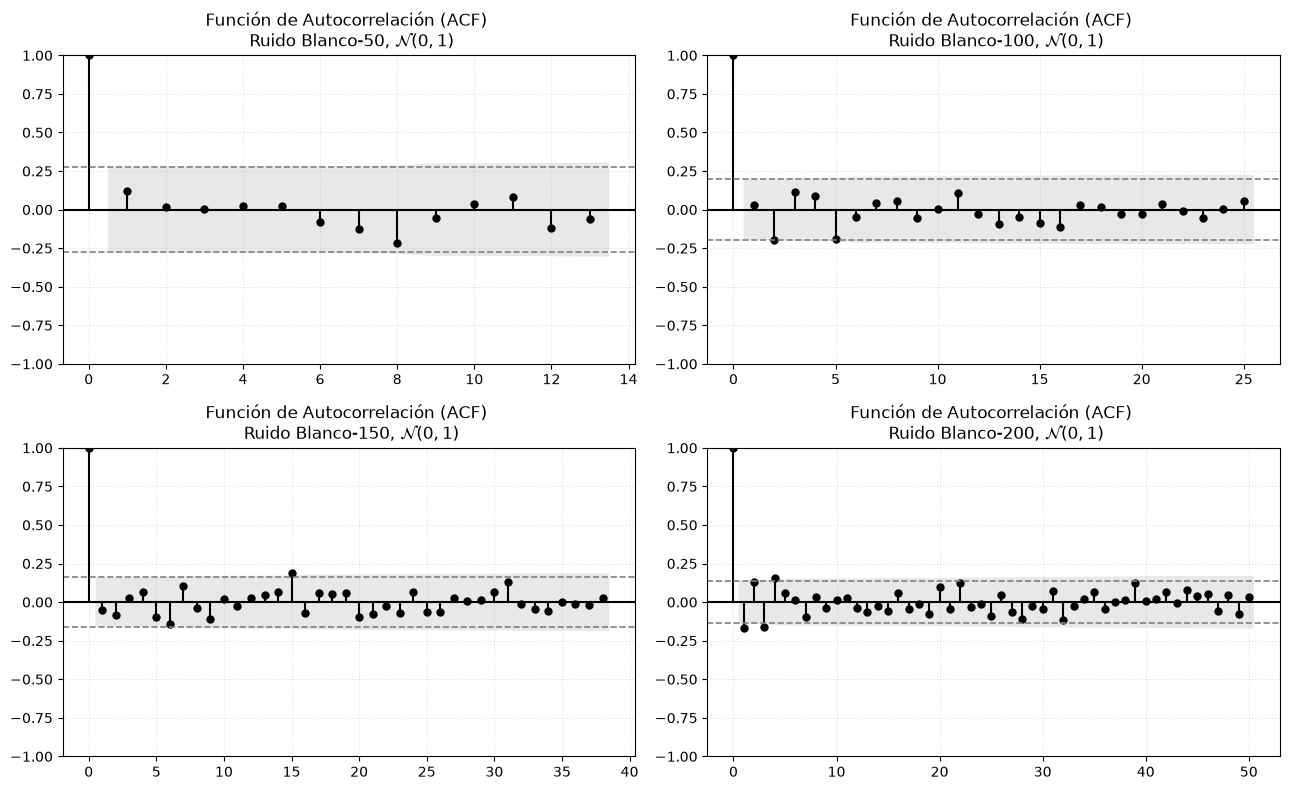

In [9]:
plt.close('all')

titulos_acf = [
    "Función de Autocorrelación (ACF) \n Ruido Blanco-50, $\\mathcal{N}(0, 1)$",
    "Función de Autocorrelación (ACF) \n Ruido Blanco-100, $\\mathcal{N}(0, 1)$",
    "Función de Autocorrelación (ACF) \n Ruido Blanco-150, $\\mathcal{N}(0, 1)$",
    "Función de Autocorrelación (ACF) \n Ruido Blanco-200, $\\mathcal{N}(0, 1)$"
]

tam_muestra_wn = [50, 100, 150, 200]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_aplanados = axes.flatten()

for i  in range(4):
    ax_actual = axes_aplanados[i]
    serie_tiempo = ls_wn[i]['white_noise']
    
    # 3. Graficar ACF activando alpha=0.05 para que genere el intervalo basal
    plot_acf(serie_tiempo, lags=cant_acf.iloc[i, 1], ax=ax_actual, alpha=0.05, 
             color="black", vlines_kwargs={"colors": "black"}, 
             title=titulos_acf[i])
        # 4. Cambiar el color de la franja/sombra a un gris suave
    for artista in ax_actual.collections:
        if isinstance(artista, plt.matplotlib.collections.PolyCollection):
            artista.set_facecolor("lightgrey") # Color gris para el fondo de la franja
            artista.set_alpha(0.5)             # Transparencia del sombreado
            
    # 5. Calcular y añadir las líneas punteadas exactas en el borde del límite (Intervalo Teórico Fijo)
    # Fórmula: 1.96 / raíz(N)
    limite = 1.96 / np.sqrt(tam_muestra_wn[i])
    
    ax_actual.axhline(y=limite, color="gray", linestyle="--", linewidth=1.2)
    ax_actual.axhline(y=-limite, color="gray", linestyle="--", linewidth=1.2)
    
    # Pequeño ajuste estético de cuadrícula de fondo
    ax_actual.grid(True, linestyle=":", alpha=0.4)

# Ajustar el espaciado para que se vea limpio
plt.tight_layout()
plt.show()

## Error Estandar de las Autocorrelaciones Estamidas y Límites de Error Estandar

El erro estandar es la desviación estandar de la distribución muestral de un estadístico muestral. Para un proceso ruido blanco el resultado
clásico de Barlett para el error estandar de los $r_k$ eadquiere la siguiente forma sencilla

$$\text{se}[r_k] \simeq \sqrt{\frac{1}{N}} \simeq \frac{1}{\sqrt{N}} \quad k > 0 \tag{11}$$

y los límites de error estandar (límites de confianza) definidos como

$$\pm z_{1-\alpha/2}\frac{1}{\sqrt{N}} = \pm \frac{z_{1-\alpha/2}}{\sqrt{N}} \tag{12}$$

que indican si las fluctuaciones en las autocorrelaciones son debidas a la aleatoriedad y cercanas a cero o hay algún indicio de dependencia temporal y es posbible que el proceso estocástico diste de ser ruido blanco. Para este caso en particular se establece una confianza del $0.95$, un $\alpha=0.05$ a dos colas que da como valor $Z = \pm 1.96$, lo que indica que es posbible que el $95%$ de las outocorrelaciones se encuentren dentro del límite y que un 5% de las autocorrelaciones estimadas se encuentran fuera. En el gráfico 3 de acf para la muestra de 150 datos vemos que hay al rededor de tres autocorrelaciones estimadas fuera de los límites que representan casi el 8% de los valores estimados. Sin embargo, esto hay que contrastarlo con lo que se viene realizando, ya que son número seudo-aleatorios es posible que sea producto del azar o que en efecto los datos al no ser puramente aleatorios contengan alguna autocorrelación. También, es posible realizar una prueba de hipótesis como el test de Ljung-Box para rechazar o no la hipótesis de ruido blanco.

Se puede verificar el valor del error estandar de las autocorrelaciones estimadas con base en la formula 11 en la columna *"error_est"*. También, el valor de los límites fijos para ruido blanco con base en la formula 12 (fijos porque la formula de Bartlett para otro tipo de proceso es dinámica y se ensancha a medida que crece), generados por la función *acf* de la librería *statsmodels*. La cual, particularmente, ajusta los valores de límites superior y límite inferior al rededor del valor de autocorrelación estimado $r_k$ y no alrededor del $0$. Por lo tanto, en la última columna *"limites_±"* se calcula el valor del límite fijo para comprobar su versidad basandose en la diferencia entre el valor de la autocorrelación estimada y su límite inferior. También, es posbible calcularla con relación al límite superior y arrojar el mismo resultado.

In [10]:
ls_acf = []

for i in range(4):
    autocorrelaciones_k, limites = acf(ls_wn[i]["white_noise"], nlags= cant_acf.iloc[i,1], alpha=0.05, bartlett_confint= False, result_object= False)
    valores_acf = np.column_stack((autocorrelaciones_k, limites))
    valores_acf_df = pd.DataFrame(valores_acf, columns=['autocorrelaciones', 'lim_inf', 'lim_sup'])
    valores_acf_df['limites_±'] = valores_acf_df['autocorrelaciones'] - valores_acf_df['lim_inf']
    valores_acf_df['error_est'] = valores_acf_df['limites_±']/1.96
    ls_acf.append(valores_acf_df)

tabs = []

for df in ls_acf:

    with pd.option_context(
        'display.max_rows', 10,
        'display.min_rows', 10
    ):
        resumen = repr(df)

    tabla = widgets.HTML(
        value=f"<pre>{resumen}</pre>"
    )
    tabs.append(widgets.VBox([tabla]))


tab = widgets.Tab(children=tabs)

for i, n in enumerate([50, 100, 150, 200]):
    tab.set_title(i, f"acf-{n}")

display(tab)

# Bibliografía

Alduncin Abitia, E. (1975). Introducción al análisis de series de tiempo. Miscelánea Matemática, (11), 40–72. https://miscelaneamatematica.org/download/tbl_articulos.pdf2.98ce0d93faaf7419.313130342e706466.pdf

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2016). Time series analysis: Forecasting and control (5.ª ed.). John Wiley & Sons.

Peña, D. (2005). Análisis de series temporales. Alianza Editorial.

Hyndman, R. J., & Athanasopoulos, G. (2026). Forecasting: Principles and Practice, the Pythonic Way. OTexts. https://otexts.com/fpppy/02-graphics.html#sec-wn